In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from simplified_phoneme_model import SimplifiedPhonemeModel
from pipeline import UnifiedPhonemePipeline

In [2]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = './features'  # Path to save extracted features
path_results = './results'  # Path to save results

In [3]:
# Pipeline creation with PCA components management
use_augmentation = True
feature_extraction_method = 'multi_band' #'high_gamma'  #
optimal_pca_components = 30  # Use your optimal value determined earlier

# Try to load existing pipeline, otherwise create new one
try:
    # Try loading existing pipeline
    pipeline = UnifiedPhonemePipeline.load_saved(path_results, method=feature_extraction_method)
    print(f"Loaded existing {feature_extraction_method} pipeline")
    
    # Check and update PCA components if needed
    current_pca = getattr(pipeline, 'pca_components', None)
    if current_pca != optimal_pca_components:
        print(f"Updating PCA components from {current_pca} to {optimal_pca_components}")
        pipeline.set_pca_components(optimal_pca_components)
        
        # Re-run data steps with new PCA components
        print("Re-processing data with updated PCA components...")
        pipeline.step4_initialize_detector()    
        pipeline.step5_accumulate_data()
        pipeline.step6_resolve_unknowns()
        pipeline.step7_filter_unknowns()
        
        # Save the updated pipeline
        pipeline.save()
        print(f"Updated and saved {feature_extraction_method} pipeline with {optimal_pca_components} PCA components")
    
except (FileNotFoundError, AttributeError, TypeError) as e:
    # No existing pipeline found, create new one
    print(f"No existing {feature_extraction_method} pipeline found. Creating new one...")
    
    pipeline = UnifiedPhonemePipeline(
        path_bids=path_bids,
        path_output=path_output,
        path_results=path_results,
        feature_extraction_method=feature_extraction_method,
        unknown_keep_ratio=0.1,
        channel_correlation_threshold=0.3,  # ADD THIS
        prioritize_regions=True,  # ADD THIS
        channel_selection='best_correlation',
        pca_components=optimal_pca_components,  # Set optimal PCA components
        debug_mode=False
    )
    
    # Run all steps
    print("Running pipeline steps...")
    pipeline.step1_initialize_decoder()
    pipeline.step2_stratify_participants()    
    pipeline.step3_create_split()
    pipeline.step4_initialize_detector()    
    pipeline.step5_accumulate_data()
    pipeline.step6_resolve_unknowns()
    pipeline.step7_filter_unknowns()
    
    # Save the pipeline
    pipeline.save()
    print(f"Created and saved new {feature_extraction_method} pipeline with {optimal_pca_components} PCA components")

# The pipeline is now ready to use with optimal PCA components
print(f"Pipeline ready with {feature_extraction_method} features and {optimal_pca_components} PCA components")

No matching pipelines found for method=multi_band, pca_components=None
No existing multi_band pipeline found. Creating new one...
PhoneticDictionary: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Pipeline initialized: multi_band, PCA=30, groups=True
Running pipeline steps...
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
Step 1: Decoder initialized with PCA components=30
CustomBrainAudioDecoder: 
Participant stratification results:
CustomBrainAudioDecoder:   Participants with most relevant channels: 3
CustomBrainAudioDecoder:   Participants with relevant channels: 4
CustomBrainAudioDecoder:   Participants with least relevant channels: 3
CustomBrainAudioDecoder: 
Top participants by channel quality:
UnifiedPhonemePipeline: Filtered to 0 participants with good coverage
CustomBrainAudioDecoder: Segmenting data for sub-01...
CustomBrainAudioDecoder: 
  Top 5 most frequent words:
CustomBrainAudioDecoder:     1. 'helft': 1 instances
CustomBrai

CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecod

CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecod

CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecoder: DEBUG: custom_feature_extraction called with method: multi_band
CustomBrainAudioDecod

In [4]:
from phonetic_dictionary import PhoneticDictionary
phonetic_dict = PhoneticDictionary()

PhoneticDictionary: Initialized with DEBUG_MODE=False


In [5]:
# Get FILTERED data (this is what you feed to the Markov model):
train_data = pipeline.get_training_data(filtered=True)  # or pipeline.train_filtered

# Extract all components:
filtered_features = train_data['features']
filtered_labels = train_data['phoneme_labels']
filtered_words = train_data['phoneme_words']
filtered_participants = train_data['phoneme_participant_ids']

test_features = pipeline.test['features']
test_labels = pipeline.test['phoneme_labels']

In [6]:
# Create a minimal version that doesn't try to reinvent your pipeline
simplified_model = SimplifiedPhonemeModel(
        phonetic_dict=phonetic_dict,
        output_dir=os.path.join(path_results, 'simplified_phoneme_model'),
        debug_mode=True
    )

SimplifiedPhonemeModel: Initialized with DEBUG_MODE=True
SimplifiedPhonemeModel: Initialized SimplifiedPhonemeModel with 7 phoneme groups
SimplifiedPhonemeModel [DEBUG]: Phoneme groups: {'alveolar': ['t', 'd', 's', 'z', 'n', 'l'], 'back_vowels': ['u', 'o', 'ɔ', 'a', 'ɑ', 'ɑu', 'œy', 'ə', 'oː', 'aː', 'ɔː', 'ɑː'], 'dorsal': ['k', 'g', 'x', 'ɣ', 'ŋ', 'χ', 'ʁ', 'ŋk'], 'front_vowels': ['i', 'ɪ', 'e', 'ɛ', 'ɛi', 'y', 'ʏ', 'eː', 'iː', 'ɪː'], 'labial': ['p', 'b', 'f', 'v', 'm', 'ʋ'], 'palatal': ['ŋ', 'j', 'r', 'tʃ', 'dʒ', 'tɕ', 'dʑ'], 'glottal': ['h', 'ɦ', 'ʔ']}


In [7]:
# Get FILTERED training data (this is important)
train_data = pipeline.get_training_data(filtered=True)
test_data = pipeline.get_test_data()
train_participant_ids = train_data.get('phoneme_participant_ids', None)
test_participant_ids = test_data.get('phoneme_participant_ids', None)

# First, check if the pipeline has completed the necessary steps
if not hasattr(pipeline, 'phonetic_dict'):
    # The phonetic dict might be in the detector
    if hasattr(pipeline, 'detector') and hasattr(pipeline.detector, 'phonetic_dict'):
        pipeline.phonetic_dict = pipeline.detector.phonetic_dict
    else:
        # Need to initialize it manually
        from phonetic_dictionary import PhoneticDictionary
        pipeline.phonetic_dict = PhoneticDictionary()

# Check if we have data after filtering
if not train_data or 'phoneme_labels' not in train_data or not train_data['phoneme_labels']:
    print("Warning: No data in filtered training set. Using unfiltered data instead.")
    # Fall back to unfiltered data
    train_data = pipeline.get_training_data(filtered=False)

# Map individual phonemes to phoneme groups
train_group_labels = []
for phoneme in train_data['phoneme_labels']:
    # Try to find the phoneme in the phoneme_to_group mapping
    if phoneme in simplified_model.phoneme_to_group:
        group = simplified_model.phoneme_to_group[phoneme]
    else:
        # If not directly mapped, search in the phoneme groups
        group = 'unknown'
        for group_name, phonemes in simplified_model.phoneme_groups.items():
            if phoneme in phonemes:
                group = group_name
                break
    train_group_labels.append(group)

In [8]:
# Do the same for test data
test_group_labels = []
for phoneme in test_data['phoneme_labels']:
    if phoneme in simplified_model.phoneme_to_group:
        group = simplified_model.phoneme_to_group[phoneme]
    else:
        group = 'unknown'
        for group_name, phonemes in simplified_model.phoneme_groups.items():
            if phoneme in phonemes:
                group = group_name
                break
    test_group_labels.append(group)

# Print the group distribution after mapping
from collections import Counter
group_counts = Counter(train_group_labels)
print("Phoneme group distribution after mapping:")
for group, count in group_counts.most_common():
    print(f"  {group}: {count}")

# Before training, check if we have enough data for each group
# If not, we might need to lower the min_occurrences
min_count = min(group_counts.values()) if group_counts else 0
recommended_min_occurrences = max(1, min(3, min_count))  # Between 1 and 3, but not more than min_count

print(f"Recommended min_occurrences: {recommended_min_occurrences}")

Phoneme group distribution after mapping:
  alveolar: 52
  back_vowels: 40
  labial: 24
  front_vowels: 15
  palatal: 11
  dorsal: 10
  glottal: 2
  unknown: 1
Recommended min_occurrences: 1


SimplifiedPhonemeModel: Training model with pre-processed phoneme group data
SimplifiedPhonemeModel: Phoneme group distribution before filtering:
SimplifiedPhonemeModel:   alveolar: 52
SimplifiedPhonemeModel:   back_vowels: 40
SimplifiedPhonemeModel:   labial: 24
SimplifiedPhonemeModel:   front_vowels: 15
SimplifiedPhonemeModel:   palatal: 11
SimplifiedPhonemeModel:   dorsal: 10
SimplifiedPhonemeModel:   glottal: 2
SimplifiedPhonemeModel:   unknown: 1
SimplifiedPhonemeModel: Training with 155 samples (filtered from 155)
SimplifiedPhonemeModel: Phoneme group distribution after filtering:
SimplifiedPhonemeModel:   alveolar: 52
SimplifiedPhonemeModel:   back_vowels: 40
SimplifiedPhonemeModel:   labial: 24
SimplifiedPhonemeModel:   front_vowels: 15
SimplifiedPhonemeModel:   palatal: 11
SimplifiedPhonemeModel:   dorsal: 10
SimplifiedPhonemeModel:   glottal: 2
SimplifiedPhonemeModel:   unknown: 1
SimplifiedPhonemeModel: Testing with 96 samples (filtered from 96)
SimplifiedPhonemeModel: Stand

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)        │ (None, 296, 30)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 296, 32)           │           4,832 │ eeg_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 296, 32)           │             128 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 148, 32)           │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 148, 64)           │          10,304 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 148, 64)           │             256 │ conv1d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 74, 64)            │               0 │ batch_normalization_1[0][… │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 128)               │          66,048 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ bidirectional[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ participant_input             │ (None, 8)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           8,256 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 16)                │             144 │ participant_input[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 64)                │             256 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 16)                │              64 │ dense_1[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 90,936 (355.22 KB)

 Trainable params: 90,584 (353.84 KB)

 Non-trainable params: 352 (1.38 KB)

SimplifiedPhonemeModel: Training model with 155 samples for up to 50 epochs
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.1320 - loss: 3.1603 - val_accuracy: 0.0312 - val_loss: 2.2774 - learning_rate: 5.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2121 - loss: 2.9199 - val_accuracy: 0.0208 - val_loss: 2.2653 - learning_rate: 5.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1558 - loss: 2.9617 - val_accuracy: 0.0521 - val_loss: 2.2604 - learning_rate: 5.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1951 - loss: 2.7471 - val_accuracy: 0.0521 - val_loss: 2.2491 - learning_rate: 5.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2307 - loss: 2.6891 - val_accuracy: 0.0521 - val_loss: 2.2398 - learning_rate: 5.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1826 - loss: 2.7030 - val_accuracy: 0.0833 - val_loss: 2.2284 - learning_rate: 5.0000e-04
Epoch

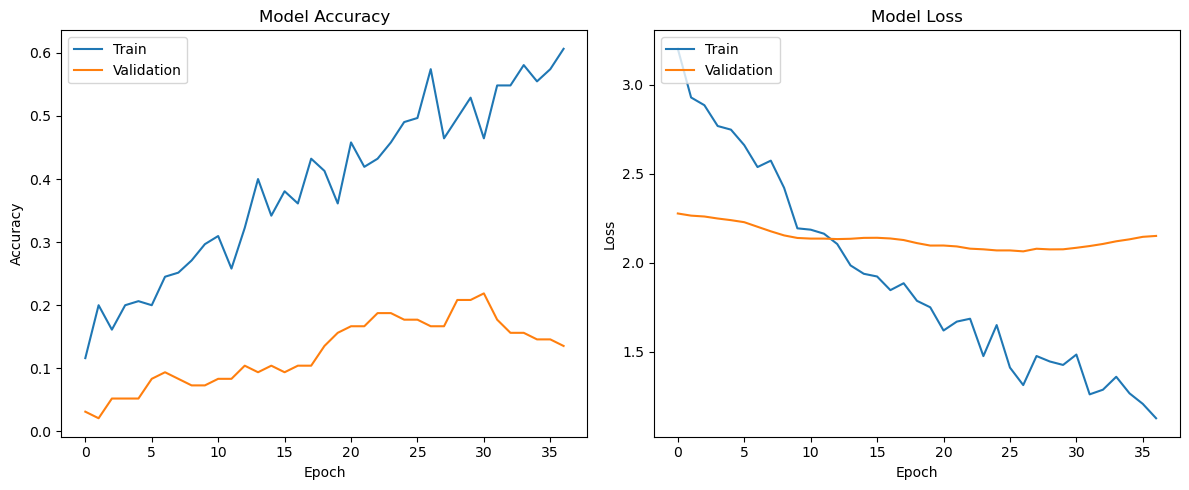

In [9]:
# 6. Train using your phoneme groups
results = simplified_model.train_with_grouped_data(
        train_features=train_data['features'],
        train_group_labels=train_group_labels,
        train_participant_ids=train_participant_ids,
        test_features=test_features,
        test_group_labels=test_group_labels,
        min_occurrences=recommended_min_occurrences,  # Use the recommended value
        test_participant_ids=test_participant_ids,
        epochs=50,
        batch_size=32,
        patience=10
    )

In [10]:
# # Initialize decoder
# custom_decoder = CustomBrainAudioDecoder(
#     path_bids=path_bids,
#     path_output=path_output,
#     path_results=path_results,
#     win_length=0.05,
#     frameshift=0.01,
#     model_order=4,
#     step_size=5,
#     n_components=50
# )
# # 7. Evaluate performance
# print(f"Simplified phoneme group model accuracy: {results['accuracy']:.4f}")
    
# # Compare to baseline
# baseline_results = custom_decoder.train_test_model(
#         participant_id='sub-08',
#         save_audio=False
#     )
# baseline_correlation = np.mean(baseline_results['correlations'])
# print(f"Baseline model correlation: {baseline_correlation:.4f}") 

Evaluation results keys: dict_keys(['loss', 'accuracy', 'confusion_matrix', 'classification_report', 'predictions', 'predicted_groups', 'true_groups', 'group_names'])
Confusion matrix shape: (8, 8)
UnifiedPhonemePipeline: Confusion matrix saved to ./results\model_viz_20250830_191633\simplified_model_confusion_matrix.png


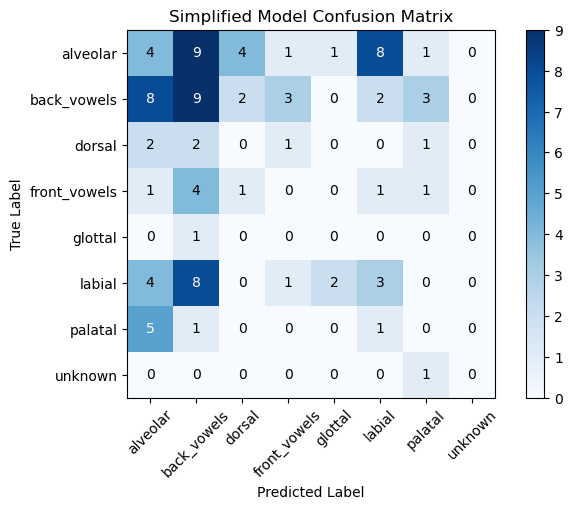

UnifiedPhonemePipeline: Metrics plot saved to ./results\model_viz_20250830_191633\simplified_model_metrics.png


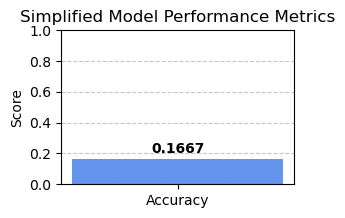

Saved files: {'confusion_matrix': './results\\model_viz_20250830_191633\\simplified_model_confusion_matrix.png', 'metrics': './results\\model_viz_20250830_191633\\simplified_model_metrics.png'}


In [11]:
evaluation_results = results
# First, check what your evaluation results contain
print("Evaluation results keys:", evaluation_results.keys())
print("Confusion matrix shape:", evaluation_results['confusion_matrix'].shape)

# Then try calling with explicit parameters
saved_files = pipeline.visualize_model_results(
    model=simplified_model,
    eval_results={
        'confusion_matrix': evaluation_results['confusion_matrix'],
        'accuracy': evaluation_results['accuracy'],
        'labels': evaluation_results['group_names']  # Make sure labels are included
    },
    title_prefix="Simplified Model",
    save_dir=path_results,
    show_plot=True
)

print("Saved files:", saved_files)

C:\Users\irina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch\simplified_phoneme_model.py:910: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(metrics_df['Phoneme Group'], rotation=45)


SimplifiedPhonemeModel: Class performance analysis saved to ./results\simplified_phoneme_model\class_performance.png
SimplifiedPhonemeModel: Class metrics saved to ./results\simplified_phoneme_model\class_metrics.csv


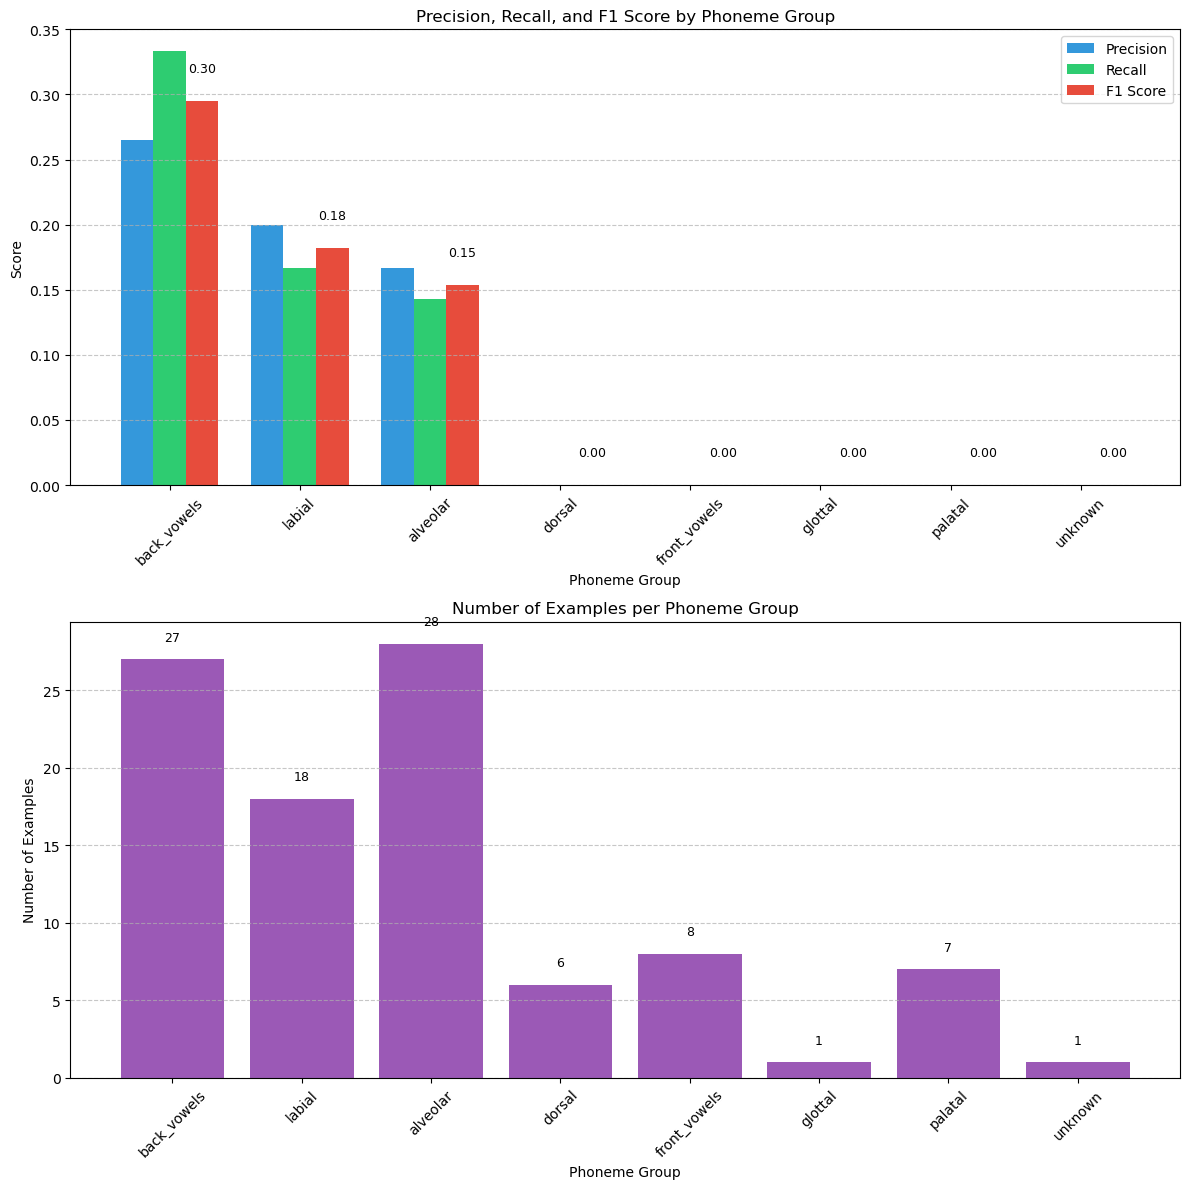

In [12]:
class_metrics = simplified_model.analyze_class_performance(
        results['true_groups'], 
        results['predicted_groups'],
        results['predictions']
    )   


In [13]:
# # Write out examples of predictions
# examples = simplified_model.analyze_examples(
#         test_data['features'],
#         results['true_groups'],
#         results['predicted_groups'],
#         test_data['phoneme_participant_ids'],
#         max_examples=3
#     )  


In [14]:
# Get FILTERED data (this is what you feed to the Markov model):
balance_strategy = 'weighted' #'undersample'#

train_data = pipeline.get_training_data(filtered=True)  # or pipeline.train_filtered

balanced_train_data = pipeline.balance_training_data(
                    train_data, 
                    balance_strategy = balance_strategy # 'weighted' #'undersample'#
                )

# Extract all components:
balanced_features = balanced_train_data['features']
balanced_labels = balanced_train_data['phoneme_labels']
balanced_words = balanced_train_data['phoneme_words']
balanced_participants = balanced_train_data['phoneme_participant_ids']

# test_features = pipeline.test['features']
# test_labels = pipeline.test['phoneme_labels']


balanced_train_parameters = {
    'features': filtered_features,
    'phoneme_labels': filtered_labels,
    'words': filtered_words,
    'participant_ids': filtered_participants
}

balanced_test_parameters = {
    'features': test_features,
    'true_labels': test_labels,  # Note: evaluate() uses 'true_labels' not 'phoneme_labels'
    'use_viterbi': True
}

UnifiedPhonemePipeline: Working with phoneme labels, mapping to groups for balancing
UnifiedPhonemePipeline: Original distribution: {'alveolar': 52, 'back_vowels': 40, 'dorsal': 10, 'labial': 24, 'palatal': 11, 'front_vowels': 15, 'glottal': 2, 'unknown': 1}
UnifiedPhonemePipeline: Balanced distribution: {'k': 24, 'ɑu': 1, 't': 10, 'r': 40, 'x': 20, 'f': 6, 'm': 8, 'z': 2, 'v': 15, 'j': 7, 'h': 57, 'ɛi': 7, 'aː': 4, 'n': 5, 'ɑ': 4, 's': 6, 'b': 6, 'd': 10, 'l': 5, 'tʋ': 9, 'eː': 3, 'oː': 1, 'ə': 7, 'a': 2, 'i': 2, 'ɪ': 5, 'ɣ': 3, 'ɛ': 1, 'ʋ': 2, 'ʏ': 1, 'p': 1}


In [15]:
# 6. Train using balanced groups
results = simplified_model.train_with_grouped_data(
        train_features = balanced_features,
        train_group_labels = balanced_labels,
        train_participant_ids = balanced_participants,
        test_features=test_features,
        test_group_labels=test_group_labels,
        min_occurrences=recommended_min_occurrences,  # Use the recommended value
        test_participant_ids=test_participant_ids,
        epochs=50,
        batch_size=32,
        patience=10
    )

SimplifiedPhonemeModel: Training model with pre-processed phoneme group data
SimplifiedPhonemeModel: Phoneme group distribution before filtering:
SimplifiedPhonemeModel:   h: 57
SimplifiedPhonemeModel:   r: 40
SimplifiedPhonemeModel:   k: 24
SimplifiedPhonemeModel:   x: 20
SimplifiedPhonemeModel:   v: 15
SimplifiedPhonemeModel:   t: 10
SimplifiedPhonemeModel:   d: 10
SimplifiedPhonemeModel:   tʋ: 9
SimplifiedPhonemeModel:   m: 8
SimplifiedPhonemeModel:   j: 7
SimplifiedPhonemeModel:   ɛi: 7
SimplifiedPhonemeModel:   ə: 7
SimplifiedPhonemeModel:   f: 6
SimplifiedPhonemeModel:   s: 6
SimplifiedPhonemeModel:   b: 6
SimplifiedPhonemeModel:   n: 5
SimplifiedPhonemeModel:   l: 5
SimplifiedPhonemeModel:   ɪ: 5
SimplifiedPhonemeModel:   aː: 4
SimplifiedPhonemeModel:   ɑ: 4
SimplifiedPhonemeModel:   eː: 3
SimplifiedPhonemeModel:   ɣ: 3
SimplifiedPhonemeModel:   z: 2
SimplifiedPhonemeModel:   a: 2
SimplifiedPhonemeModel:   i: 2
SimplifiedPhonemeModel:   ʋ: 2
SimplifiedPhonemeModel:   ɑu: 1
Simpl

In [16]:
evaluation_results = results
# First, check what your evaluation results contain
print("Evaluation results keys:", evaluation_results.keys())
print("Confusion matrix shape:", evaluation_results['confusion_matrix'].shape)

# Then try calling with explicit parameters
saved_files = pipeline.visualize_model_results(
    model=simplified_model,
    eval_results={
        'confusion_matrix': evaluation_results['confusion_matrix'],
        'accuracy': evaluation_results['accuracy'],
        'labels': evaluation_results['group_names']  # Make sure labels are included
    },
    title_prefix="Simplified Model",
    save_dir=path_results,
    show_plot=True
)

print("Saved files:", saved_files)

AttributeError: 'NoneType' object has no attribute 'keys'